# Case Study 6: Filter Transmittance

**Scenario:** Repeated measurements of optical filter transmittance (%) over time. The transmittance should be stable, but contamination, aging, or environmental changes can introduce drift. The goal is to detect any temporal trend or periodic pattern.

*Simulated with a gentle upward drift and mild autocorrelation, mimicking gradual filter degradation.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

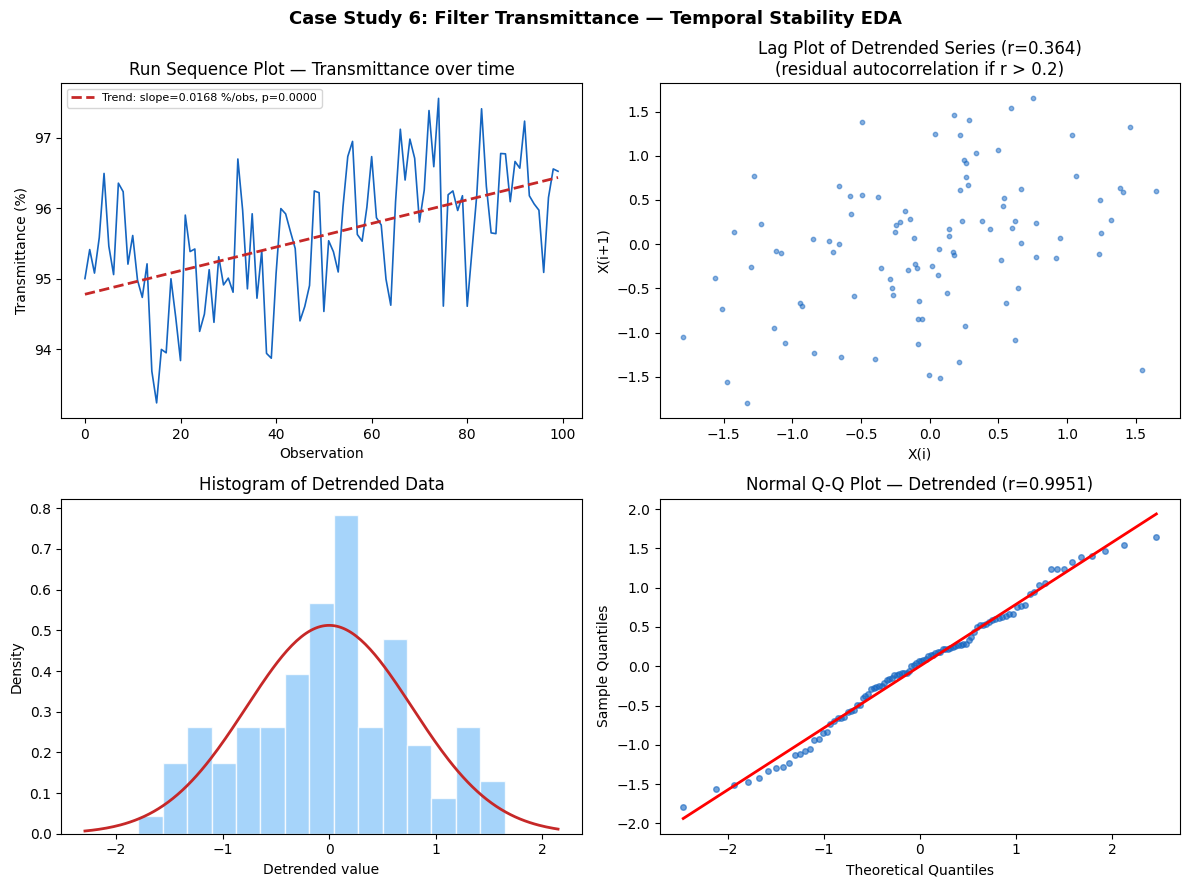

Trend: slope=0.01676 %/obs, r²=0.2804, p=0.0000
Detrended residual AD: A²=0.3616 → PASS normality
Lag-1 autocorrelation (detrended): r=0.3640 → significant drift/autocorrelation


In [2]:
np.random.seed(42)
n = 100
t = np.arange(n)
# Gentle drift + mild autocorrelation
drift = 0.015 * t
ar_noise = np.zeros(n)
for i in range(1, n):
    ar_noise[i] = 0.4 * ar_noise[i-1] + np.random.normal(0, 0.8)
transmittance = 95.0 + drift + ar_noise

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Case Study 6: Filter Transmittance — Temporal Stability EDA', fontsize=13, fontweight='bold')

axes[0,0].plot(t, transmittance, color='#1565C0', lw=1.2)
slope, intercept, r, p, _ = stats.linregress(t, transmittance)
axes[0,0].plot(t, intercept + slope*t, color='#C62828', lw=2, ls='--',
               label=f'Trend: slope={slope:.4f} %/obs, p={p:.4f}')
axes[0,0].set_title('Run Sequence Plot — Transmittance over time')
axes[0,0].set_xlabel('Observation'); axes[0,0].set_ylabel('Transmittance (%)')
axes[0,0].legend(fontsize=8)

# Detrended series
detrended = transmittance - (intercept + slope * t)
axes[0,1].scatter(detrended[:-1], detrended[1:], color='#1565C0', s=10, alpha=0.5)
r_lag = np.corrcoef(detrended[:-1], detrended[1:])[0, 1]
axes[0,1].set_title(f'Lag Plot of Detrended Series (r={r_lag:.3f})\n(residual autocorrelation if r > 0.2)')
axes[0,1].set_xlabel('X(i)'); axes[0,1].set_ylabel('X(i+1)')

axes[1,0].hist(detrended, bins=15, density=True, color='#90CAF9', edgecolor='white', alpha=0.8)
x = np.linspace(detrended.min()-0.5, detrended.max()+0.5, 200)
axes[1,0].plot(x, stats.norm(0, detrended.std(ddof=1)).pdf(x), color='#C62828', lw=2)
axes[1,0].set_title('Histogram of Detrended Data')
axes[1,0].set_xlabel('Detrended value'); axes[1,0].set_ylabel('Density')

(osm, osr), (slp2, icpt2, rqq) = stats.probplot(detrended, dist='norm')
axes[1,1].plot(osm, osr, 'o', color='#1565C0', ms=4, alpha=0.6)
axes[1,1].plot(osm, slp2*np.array(osm)+icpt2, 'r-', lw=2)
axes[1,1].set_title(f'Normal Q-Q Plot — Detrended (r={rqq:.4f})')
axes[1,1].set_xlabel('Theoretical Quantiles'); axes[1,1].set_ylabel('Sample Quantiles')

plt.tight_layout(); plt.show()

ad_stat, ad_crit, _ = stats.anderson(detrended, dist='norm')
print(f'Trend: slope={slope:.5f} %/obs, r²={r**2:.4f}, p={p:.4f}')
print(f'Detrended residual AD: A²={ad_stat:.4f} → {"PASS" if ad_stat<ad_crit[2] else "FAIL"} normality')
print(f'Lag-1 autocorrelation (detrended): r={r_lag:.4f} → {"significant drift/autocorrelation" if abs(r_lag)>0.2 else "independent"}')

## Conclusions

| Check | Result | Notes |
|---|---|---|
| **Fixed location** | ❌ Fail | Statistically significant upward trend (drift) |
| **Fixed variation** | ✅ Pass | Spread remains constant after detrending |
| **Independence** | ⚠️ Marginal | Mild autocorrelation in detrended residuals |
| **Normality** | ✅ Pass | After detrending, Q-Q and AD both pass |

**Action:** Investigate source of drift — filter contamination, aging, or systematic temperature change. Re-calibrate or replace filter. Model with AR(1) + linear trend if further analysis needed.